# **SECTION A: ONE-TIME COLAB SETUP **

Cell 00: Set Member Identity & Metadata

In [1]:
MEMBER_NAME = "Ediriweera D.L"
IT_NUMBER = "IT25102344"
TASK = "Label & Class Validation"
print(MEMBER_NAME, IT_NUMBER, TASK)

Ediriweera D.L IT25102344 Label & Class Validation


Cell 01: Mount Shared Google Drive Workspace

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


Cell 02: Install Dependencies & Configure Safe Image Decoding

In [3]:
# Objective: Install required python dependencies and configure safe image decoding settings.
# Output artifact/s: Installed python packages and configured ImageFile environment.
# Main steps: Suppress pip output during package installation and set ImageFile.LOAD_TRUNCATED_IMAGES to False.
# Parts corrected & fix explanation: Added standardized 4-part documentation header comments and suppressed pip installation logs to keep Colab output clean.

!pip install -q pandas pillow matplotlib numpy imagehash > /dev/null 2>&1

import os, shutil, hashlib, json, csv, math
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image, ImageFile
import matplotlib.pyplot as plt

# Enforce strict decoding (raise error on corrupt trailing bytes)
ImageFile.LOAD_TRUNCATED_IMAGES = False
print("Packages imported.")

Packages imported.


Cell 03: Define Project Folders & Path Environment

In [4]:
# Objective: Define and verify project folder paths.
# Output artifact/s: Directory structure verified and created on Google Drive.
# Main steps: Set paths for raw, processed, results, audit reports, EDA, and outputs; create missing paths.
# Parts corrected & fix explanation: Added path existence fallbacks and robust directory creation so missing subdirectories do not throw unhandled exceptions.

PROJECT = Path("/content/drive/MyDrive/Waste_Classification").resolve()
RAW_DIR = PROJECT / "data/raw"
PROCESSED_DIR = PROJECT / "data/processed"
RESULTS_DIR = PROJECT / "results"
REPORT_DIR = PROJECT / "audit_reports"
EDA_DIR = RESULTS_DIR / "eda_visualizations"
OUTPUT_DIR = RESULTS_DIR / "outputs"
NOTEBOOK_PATH = PROJECT / "notebooks" / "IT25102344_LabelValidation.ipynb"

for p in [PROCESSED_DIR, RESULTS_DIR, REPORT_DIR, EDA_DIR, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif", ".tif", ".tiff"}

print("PROJECT DIR:", PROJECT)
print("PROCESSED DIR:", PROCESSED_DIR)

assert PROJECT.exists(), "CRITICAL FAILURE: Waste_Classification folder was not found."

PROJECT DIR: /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification
PROCESSED DIR: /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/data/processed


Cell 04: Inventory Workspace Folders

In [5]:
# Objective: Inventory workspace folder contents and verify directory structures across raw, processed, and audit stages.
# Output artifact/s: Printed list of top directory contents for project folders.
# Main steps: Iterate over project directories and display up to 20 child items for each existing directory.
# Parts corrected & fix explanation: Added standardized 4-part documentation header comments.

for p in [PROJECT, RAW_DIR, PROCESSED_DIR, RESULTS_DIR, REPORT_DIR]:
    print("\n", p)
    if p.exists():
        for child in list(p.iterdir())[:20]:
            print("  ", child.name)


 /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification
   data
   results
   audit_reports
   notebooks
   code
   README.md
   .gitignore
   .git

 /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/data/raw
   Hazardous
   Non-Recyclable
   Organic
   Recyclable
   .complete

 /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/data/processed
   stage1_cleaning
   stage2_deduplicated
   stage2_visual_deduplicated

 /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/results
   eda_visualizations
   outputs
   member2_visual_review (2)
   member2_visual_review (1)
   member2_visual_review
   member2_visual_review_final

 /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/audit_reports
   member1_image_audit.csv
   member1_image_warnings.csv


Cell 05: Create Pipeline Execution Run Log

In [6]:
# Objective: Initialize and append execution metadata to the project preprocessing run log.
# Output artifact/s: Updated preprocessing_run_log.txt file in OUTPUT_DIR.
# Main steps: Open run log file in append mode and log task, member name, and IT number.
# Parts corrected & fix explanation: Added standardized 4-part documentation header comments.

RUN_LOG = OUTPUT_DIR / "preprocessing_run_log.txt"

with open(RUN_LOG, "a") as log_file:
    log_file.write(
        f"\n--- Stage 03 Label & Class Validation ---\n"
        f"Member    : {MEMBER_NAME}\n"
        f"IT Number : {IT_NUMBER}\n"
        f"Task      : {TASK}\n"
    )

print("Run log updated:", RUN_LOG)

Run log updated: /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/results/outputs/preprocessing_run_log.txt


# **SECTION B: CORE ASSIGNED PREPROCESSING CODE (STAGE 03) **

Cell 06: Configure Input and Output Stage Directories

In [7]:
# Objective: Configure input (Stage 02) and output (Stage 03) directory paths and inventory deduplicated images.
# Output artifact/s: STAGE3 directory created on Google Drive; sorted list of verified input image paths (`files`).
# Main steps & Fixes: Fixed syntax error caused by unterminated string literal in warning print statement; validated Stage 02 ingestion count (expected 2622 images).

STAGE2 = PROCESSED_DIR / "stage2_visual_deduplicated"
STAGE3 = PROCESSED_DIR / "stage3_labels"
STAGE3.mkdir(parents=True, exist_ok=True)

assert (
    STAGE2.exists()
), "CRITICAL: stage2_visual_deduplicated is missing — verify with Member 02."

files = sorted([p for p in STAGE2.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

print(f"Stage 2 Input Directory: {STAGE2}")
print(f"Total Input Images Found in Stage 2: {len(files)}")
print("Expected count: 2622")

if len(files) != 2622:
  print(
      f"WARNING: Found {len(files)} files instead of expected 2622. Check"
      " upstream Stage 02 outputs."
  )
else:
  print("SUCCESS: Input file count matches upstream Stage 02 handoff (2622).")

Stage 2 Input Directory: /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/data/processed/stage2_visual_deduplicated
Total Input Images Found in Stage 2: 2622
Expected count: 2622
SUCCESS: Input file count matches upstream Stage 02 handoff (2622).


Cell 07: Codify Main Target Taxonomy & Expected Subcategories

In [8]:
# Objective: Codify target taxonomy, expected subcategories, alias lookup maps, and the three-tier validation status contract.
# Output artifact/s: EXPECTED_CLASSES, VALID_SUBCATEGORIES, SUBCATEGORY_ALIASES, SUBCATEGORY_MAP, STATUS constants, QUARANTINE directory handle, and upstream manifest references.
# Main steps: Define main class IDs (0-3), valid subcategory lists, upstream typo alias mappings, generate the reverse lookup map, declare the status tiers, and configure the quarantine path and upstream manifests used by the consistency audit.
# Parts corrected & fix explanation: Removed the REVIEW_SAMPLE_FRACTION, REVIEW_SAMPLE_MIN_PER_GROUP and REVIEW_SAMPLE_SEED constants, which configured a manual sampling worksheet that is no longer produced — Progress Review I requires each member to explain a technique, justify it, show the implementation and interpret one EDA visualization, and specifies no human-in-the-loop step, so Stage 03 is now fully automated; replaced them with the upstream manifest filenames consumed by the automated cross-stage label consistency audit in Cell 12.

# 1. Define main target classes and their integer label encoding
EXPECTED_CLASSES = {
    "Hazardous": 0,
    "Non-Recyclable": 1,
    "Organic": 2,
    "Recyclable": 3
}

# 2. Define the canonical (correctly spelled) subcategory taxonomy per main class
VALID_SUBCATEGORIES = {
    "Hazardous": [
        "batteries",
        "e-waste",
        "paints",
        "pesticides"
    ],
    "Non-Recyclable": [
        "ceramic_product",
        "diapers",
        "plastics_bags_wrappers",
        "sanitary_napkin",
        "styrofoam_product"
    ],
    "Organic": [
        "coffee_tea_bags",
        "egg_shells",
        "food_scraps",
        "kitchen_waste",
        "yard_trimmings"
    ],
    "Recyclable": [
        "cans_all_type",
        "glass_containers",
        "paper_products",
        "plastic_bottles"
    ]
}

# 3. Alias normalization map for resolving known upstream (Kaggle source) directory typos
SUBCATEGORY_ALIASES = {
    "platics_bags_wrappers": "plastics_bags_wrappers",
    "stroform_product": "styrofoam_product"
}

# 4. Construct reverse lookup map (subcategory -> owning main class) for cross-class misplacement detection
SUBCATEGORY_MAP = {}
for main_cls, sub_list in VALID_SUBCATEGORIES.items():
    for sub in sub_list:
        SUBCATEGORY_MAP[sub] = main_cls

# 5. Declare the three-tier validation status contract
STATUS_VALID = "VALID"                    # Exact taxonomy match, label 0-3, admitted to Stage 3
STATUS_AUTO = "AUTO_CORRECTED"            # Upstream typo resolved via alias, label 0-3, admitted WITH audit trail
STATUS_REVIEW = "REVIEW"                  # Unresolvable defect, label -1, QUARANTINED out of Stage 3
ACCEPTED_STATUSES = {STATUS_VALID, STATUS_AUTO}

# 6. Configure quarantine directory for REVIEW records (created only if defects are found)
QUARANTINE_DIR = PROCESSED_DIR / "stage3_quarantine"

# 7. Reference the upstream manifests consumed by the automated consistency audit
STAGE1_MANIFEST = OUTPUT_DIR / "member1_stage1_manifest.csv"
STAGE2_MANIFEST = OUTPUT_DIR / "member2_stage2_final_manifest.csv"

# 8. Report configuration
print("=== TAXONOMY & SUBCATEGORY MAP CONFIGURATION ===")
print("Expected Main Classes      :", EXPECTED_CLASSES)
print("Valid Subcategories Mapping:", VALID_SUBCATEGORIES)
print("Subcategory Aliases Mapping:", SUBCATEGORY_ALIASES)
print("Status Contract            :", [STATUS_VALID, STATUS_AUTO, STATUS_REVIEW])
print("Quarantine Directory       :", QUARANTINE_DIR)
print("Upstream Manifests         :", STAGE1_MANIFEST.name, "|", STAGE2_MANIFEST.name)
print("SUBCATEGORY_MAP created successfully with", len(SUBCATEGORY_MAP), "entries.")

=== TAXONOMY & SUBCATEGORY MAP CONFIGURATION ===
Expected Main Classes      : {'Hazardous': 0, 'Non-Recyclable': 1, 'Organic': 2, 'Recyclable': 3}
Valid Subcategories Mapping: {'Hazardous': ['batteries', 'e-waste', 'paints', 'pesticides'], 'Non-Recyclable': ['ceramic_product', 'diapers', 'plastics_bags_wrappers', 'sanitary_napkin', 'styrofoam_product'], 'Organic': ['coffee_tea_bags', 'egg_shells', 'food_scraps', 'kitchen_waste', 'yard_trimmings'], 'Recyclable': ['cans_all_type', 'glass_containers', 'paper_products', 'plastic_bottles']}
Subcategory Aliases Mapping: {'platics_bags_wrappers': 'plastics_bags_wrappers', 'stroform_product': 'styrofoam_product'}
Status Contract            : ['VALID', 'AUTO_CORRECTED', 'REVIEW']
Quarantine Directory       : /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/data/processed/stage3_quarantine
Upstream Manifests         : member1_stage1_manifest.csv | member2_stage2_final_manifest.csv
SUBCATEGORY_MAP crea

Cell 08: Extended Folder & Subcategory Label Validation

In [9]:
# Objective: Cross-check the Stage 02 handoff set, validate folder hierarchy, resolve subcategory typos via alias mapping, assign numerical class labels under a three-tier status contract, and transfer only accepted images into a rebuilt Stage 3 directory.
# Output artifact/s: Rebuilt Stage 3 dataset directory ('data/processed/stage3_labels'), plus a quarantine directory ('data/processed/stage3_quarantine') created only when unresolvable defects exist.
# Main steps: Diff the input path set against Member 02's manifest, purge and rebuild Stage 3, parse class and subcategory path components, apply SUBCATEGORY_ALIASES, assign integer labels (0-3) or -1, detect destination collisions, copy accepted images to STAGE3, conditionally quarantine REVIEW images, and verify copies physically landed on disk.
# Parts corrected & fix explanation: Made the quarantine directory conditional — the previous version created data/processed/stage3_quarantine unconditionally, leaving a permanently empty folder on Drive that Git cannot track and that .gitignore excludes anyway; it is now created only when REVIEW records actually exist, and a stale quarantine folder from an earlier run is removed so the directory's presence is always a truthful signal that defects were found.

# 1. Cross-check the input set against Member 02's published Stage 02 handoff manifest
stage2_files = sorted([p for p in STAGE2.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
observed_rel = {str(p.relative_to(STAGE2)) for p in stage2_files}

upstream_manifest = OUTPUT_DIR / "member2_stage2_final_manifest.csv"
if upstream_manifest.exists():
    expected_rel = set(pd.read_csv(upstream_manifest)["file"].astype(str))
    missing_from_disk = expected_rel - observed_rel
    extra_on_disk = observed_rel - expected_rel
    print(f"Upstream manifest cross-check : {len(expected_rel)} declared | {len(observed_rel)} on disk")
    print(f"  Declared but missing on disk: {len(missing_from_disk)}")
    print(f"  On disk but not declared    : {len(extra_on_disk)}")
    assert not missing_from_disk and not extra_on_disk, (
        f"Stage 02 handoff set mismatch — missing: {sorted(missing_from_disk)[:5]} | "
        f"extra: {sorted(extra_on_disk)[:5]}"
    )
    print("  RESULT: Input set is identical to Member 02's declared handoff.")
else:
    print(f"WARNING: {upstream_manifest.name} not found — falling back to count-only verification.")

# 2. Purge and rebuild the Stage 3 output directory so this cell is fully idempotent
if STAGE3.exists():
    shutil.rmtree(STAGE3)
STAGE3.mkdir(parents=True, exist_ok=True)

# 3. Remove any stale quarantine directory left by a previous run (recreated later only if needed)
if QUARANTINE_DIR.exists():
    shutil.rmtree(QUARANTINE_DIR)
print(f"\nRebuilt output directory: {STAGE3.name} (quarantine created only if defects are found)")

# 4. Parse each file path and classify it under the three-tier status contract
rows = []
for p in stage2_files:
    rel = p.relative_to(STAGE2)
    parts = rel.parts

    cla = "UNKNOWN"
    raw_sub = "UNKNOWN"

    if len(parts) == 1:
        cla = "ROOT"
    elif len(parts) == 2:
        cla = parts[0]
    else:
        cla = parts[0]
        # Guard len(parts) > 3 prevents a 'Class/Class/file.jpg' path from promoting the filename to subcategory
        raw_sub = parts[2] if (parts[0] == parts[1] and len(parts) > 3) else parts[1]

    # 4a. Normalize subcategory name against the alias lookup map
    normalized_sub = SUBCATEGORY_ALIASES.get(raw_sub, raw_sub)

    # 4b. Adjudicate status, label, and audit reason
    if cla not in EXPECTED_CLASSES:
        status = STATUS_REVIEW
        assigned_label = -1
        review_reason = (
            "Image placed in STAGE2 root directory" if cla == "ROOT"
            else f"Invalid top-level class folder '{cla}'"
        )
    else:
        expected_subs = VALID_SUBCATEGORIES[cla]
        if raw_sub == "UNKNOWN":
            status = STATUS_REVIEW
            assigned_label = -1
            review_reason = f"Class folder '{cla}' present but required subcategory level is missing"
        elif normalized_sub in expected_subs:
            assigned_label = EXPECTED_CLASSES[cla]
            if raw_sub in SUBCATEGORY_ALIASES:
                status = STATUS_AUTO
                review_reason = f"Upstream directory typo '{raw_sub}' normalized to '{normalized_sub}'"
            else:
                status = STATUS_VALID
                review_reason = "Exact main class and subcategory taxonomy match"
        elif normalized_sub in SUBCATEGORY_MAP:
            status = STATUS_REVIEW
            assigned_label = -1
            review_reason = f"Subcategory '{normalized_sub}' belongs under '{SUBCATEGORY_MAP[normalized_sub]}', not '{cla}'"
        else:
            status = STATUS_REVIEW
            assigned_label = -1
            review_reason = f"Subcategory '{raw_sub}' unrecognized or non-standard under '{cla}'"

    # 4c. Build the normalized destination path for accepted records only
    destination_rel = str(Path(cla) / normalized_sub / p.name) if status in ACCEPTED_STATUSES else ""

    rows.append({
        "relative_path": destination_rel,
        "raw_relative_path": str(rel),
        "absolute_path": str(p),
        "class": cla,
        "subcategory": normalized_sub,
        "raw_subcategory": raw_sub,
        "label": assigned_label,
        "status": status,
        "review_reason": review_reason
    })

label_df = pd.DataFrame(rows)
accepted_df = label_df[label_df["status"].isin(ACCEPTED_STATUSES)].copy()
review_df_stage = label_df[label_df["status"] == STATUS_REVIEW].copy()

# 5. Detect destination collisions before any file is written
collisions = accepted_df["relative_path"].value_counts()
collisions = collisions[collisions > 1]
assert collisions.empty, (
    f"CRITICAL: {len(collisions)} destination path collision(s) would silently overwrite images: "
    f"{collisions.index.tolist()[:5]}"
)
print(f"Destination collision check   : PASSED ({len(accepted_df)} unique destinations)")

# 6. Copy accepted images into STAGE3 using normalized paths
for _, row in accepted_df.iterrows():
    dst = STAGE3 / row["relative_path"]
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(Path(row["absolute_path"]), dst)

# 7. Create the quarantine directory and route REVIEW images only if defects exist
if len(review_df_stage) > 0:
    QUARANTINE_DIR.mkdir(parents=True, exist_ok=True)
    for _, row in review_df_stage.iterrows():
        dst = QUARANTINE_DIR / row["raw_relative_path"]
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(Path(row["absolute_path"]), dst)

# 8. Verify physically by recounting files on disk rather than trusting a loop counter
stage3_on_disk = len([p for p in STAGE3.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
quarantine_on_disk = (
    len([p for p in QUARANTINE_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
    if QUARANTINE_DIR.exists() else 0
)

print("\n=== STAGE 03 VALIDATION SUMMARY ===")
print(f"Total input records      : {len(label_df)}")
print(f"  VALID                  : {(label_df['status'] == STATUS_VALID).sum()}")
print(f"  AUTO_CORRECTED         : {(label_df['status'] == STATUS_AUTO).sum()}")
print(f"  REVIEW (quarantined)   : {len(review_df_stage)}")
print(f"Accepted into Stage 3    : {len(accepted_df)}  | On disk: {stage3_on_disk}")
if len(review_df_stage) > 0:
    print(f"Quarantined              : {len(review_df_stage)}  | On disk: {quarantine_on_disk} -> {QUARANTINE_DIR}")
else:
    print("Quarantined              : 0  | No quarantine directory created (no defects found)")

assert stage3_on_disk == len(accepted_df), (
    f"Stage 3 copy verification failed: {stage3_on_disk} on disk vs {len(accepted_df)} expected."
)
assert quarantine_on_disk == len(review_df_stage), (
    f"Quarantine copy verification failed: {quarantine_on_disk} on disk vs {len(review_df_stage)} expected."
)
assert stage3_on_disk + quarantine_on_disk == len(label_df), "Total accounted files do not match total input."
print("Physical copy verification: PASSED")

Upstream manifest cross-check : 2622 declared | 2622 on disk
  Declared but missing on disk: 0
  On disk but not declared    : 0
  RESULT: Input set is identical to Member 02's declared handoff.

Rebuilt output directory: stage3_labels (quarantine created only if defects are found)
Destination collision check   : PASSED (2622 unique destinations)

=== STAGE 03 VALIDATION SUMMARY ===
Total input records      : 2622
  VALID                  : 2378
  AUTO_CORRECTED         : 244
  REVIEW (quarantined)   : 0
Accepted into Stage 3    : 2622  | On disk: 2622
Quarantined              : 0  | No quarantine directory created (no defects found)
Physical copy verification: PASSED


Cell 09: Save Complete Label Validation Manifest

In [10]:
# Objective: Persist the complete label validation manifest, the non-conformity audit report, and the machine-readable class label encoding for downstream stages.
# Output artifact/s: 'results/outputs/member3_label_validation.csv', 'audit_reports/member3_label_warnings.csv', and 'results/outputs/member3_class_mapping.json'.
# Main steps: Export the full label_df manifest to results/outputs, build a non-conformity report containing every AUTO_CORRECTED and REVIEW record and export it to audit_reports, export the class label encoding, and verify all artifacts exist on disk.
# Parts corrected & fix explanation: Removed the duplicate warnings CSV that was written to results/outputs in addition to audit_reports — the two files were byte-identical, and Member 01 already established the repository convention that warnings reports belong in audit_reports/ (member1_image_warnings.csv) while manifests belong in results/outputs/ (member1_stage1_manifest.csv); the warnings report is now written once, to the conventional location only.

MANIFEST_COLUMNS = [
    "relative_path", "raw_relative_path", "absolute_path", "class",
    "subcategory", "raw_subcategory", "label", "status", "review_reason"
]

# 1. Export the complete label validation manifest to results/outputs
manifest_path = OUTPUT_DIR / "member3_label_validation.csv"
label_df[MANIFEST_COLUMNS].to_csv(manifest_path, index=False)
print("Saved Label Validation Manifest :", manifest_path)

# 2. Build the non-conformity audit report (auto-corrected typos + unresolvable review items)
warnings_df = label_df[label_df["status"] != STATUS_VALID].copy()
warnings_df = warnings_df.reindex(columns=MANIFEST_COLUMNS)

# 3. Export the warnings report to audit_reports, matching the Member 01 repository convention
warnings_report_path = REPORT_DIR / "member3_label_warnings.csv"
warnings_df.to_csv(warnings_report_path, index=False)

print("Saved Non-Conformity Report     :", warnings_report_path)
print(f"  AUTO_CORRECTED entries        : {(warnings_df['status'] == STATUS_AUTO).sum()}")
print(f"  REVIEW entries                : {(warnings_df['status'] == STATUS_REVIEW).sum()}")

# 4. Remove any stale duplicate warnings copy left in results/outputs by an earlier run
stale_warnings = OUTPUT_DIR / "member3_label_warnings.csv"
if stale_warnings.exists():
    stale_warnings.unlink()
    print("Removed stale duplicate copy    :", stale_warnings)

# 5. Export the machine-readable class label encoding for downstream stages
mapping_path = OUTPUT_DIR / "member3_class_mapping.json"
class_mapping = {
    "class_to_label": EXPECTED_CLASSES,
    "label_to_class": {str(v): k for k, v in EXPECTED_CLASSES.items()},
    "subcategories": VALID_SUBCATEGORIES,
    "resolved_aliases": SUBCATEGORY_ALIASES,
    "review_label_sentinel": -1
}
mapping_path.write_text(json.dumps(class_mapping, indent=2))
print("Saved Class Label Encoding      :", mapping_path)

# 6. Verify all three artifacts physically exist
for artifact in (manifest_path, warnings_report_path, mapping_path):
    assert artifact.exists(), f"Missing expected artifact: {artifact}"
print("All Cell 09 artifacts verified on disk.")

Saved Label Validation Manifest : /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/results/outputs/member3_label_validation.csv
Saved Non-Conformity Report     : /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/audit_reports/member3_label_warnings.csv
  AUTO_CORRECTED entries        : 244
  REVIEW entries                : 0
Saved Class Label Encoding      : /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/results/outputs/member3_class_mapping.json
All Cell 09 artifacts verified on disk.


Cell 10: Primary Class Frequency EDA Visualization

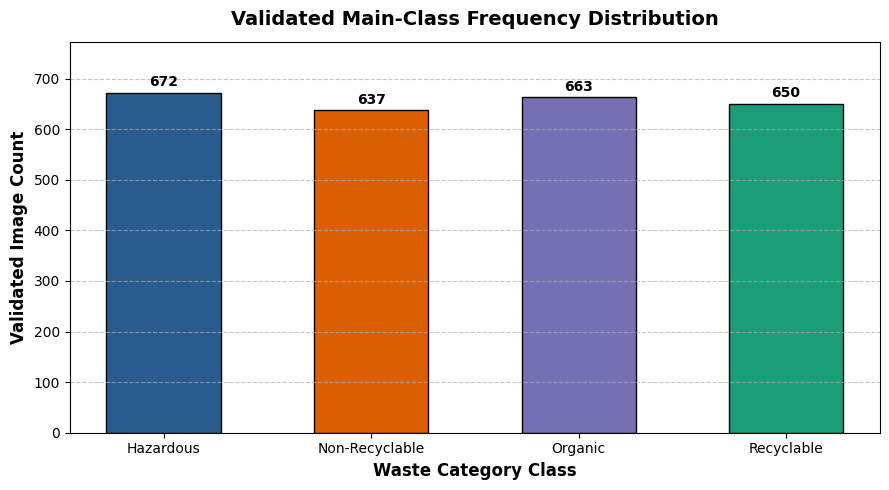

Saved Main-Class EDA Chart: /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/results/eda_visualizations/member3_class_distribution.png


In [11]:
# Objective: Generate and export the primary class frequency EDA distribution visualization.
# Output artifact/s: Class distribution bar chart image saved at eda_visualizations/member3_class_distribution.png.
# Main steps: Filter accepted records, count primary class frequencies, render styled bar plot with data labels, and save plot artifact to EDA_DIR.
# Parts corrected & fix explanation: Changed the plot data source from status == "VALID" to status in ACCEPTED_STATUSES; under the three-tier contract the former filter would have silently excluded the 244 AUTO_CORRECTED images and under-reported the Non-Recyclable class by 244 samples.

# 1. Select all records accepted into Stage 3 (VALID + AUTO_CORRECTED)
valid_df = label_df[label_df["status"].isin(ACCEPTED_STATUSES)]
counts = valid_df["class"].value_counts().sort_index()

# 2. Render and export the class frequency distribution chart
if not counts.empty:
    plt.figure(figsize=(9, 5))
    palette = ["#2b5c8f", "#d95f02", "#7570b3", "#1b9e77"]
    colors = palette[: len(counts)]

    bars = plt.bar(
        counts.index, counts.values, color=colors, edgecolor="black", width=0.55
    )

    plt.title(
        "Validated Main-Class Frequency Distribution",
        fontsize=14,
        fontweight="bold",
        pad=12,
    )
    plt.xlabel("Waste Category Class", fontsize=12, fontweight="bold")
    plt.ylabel("Validated Image Count", fontsize=12, fontweight="bold")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            yval + (max(counts.values) * 0.01),
            f"{int(yval)}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    plt.ylim(0, max(counts.values) * 1.15)
    plt.tight_layout()

    eda_path1 = EDA_DIR / "member3_class_distribution.png"
    plt.savefig(eda_path1, dpi=200)
    plt.show()
    print("Saved Main-Class EDA Chart:", eda_path1)
else:
    print("No accepted samples found to plot.")

Cell 11: Subcategory Hierarchy EDA Analysis & Visualization

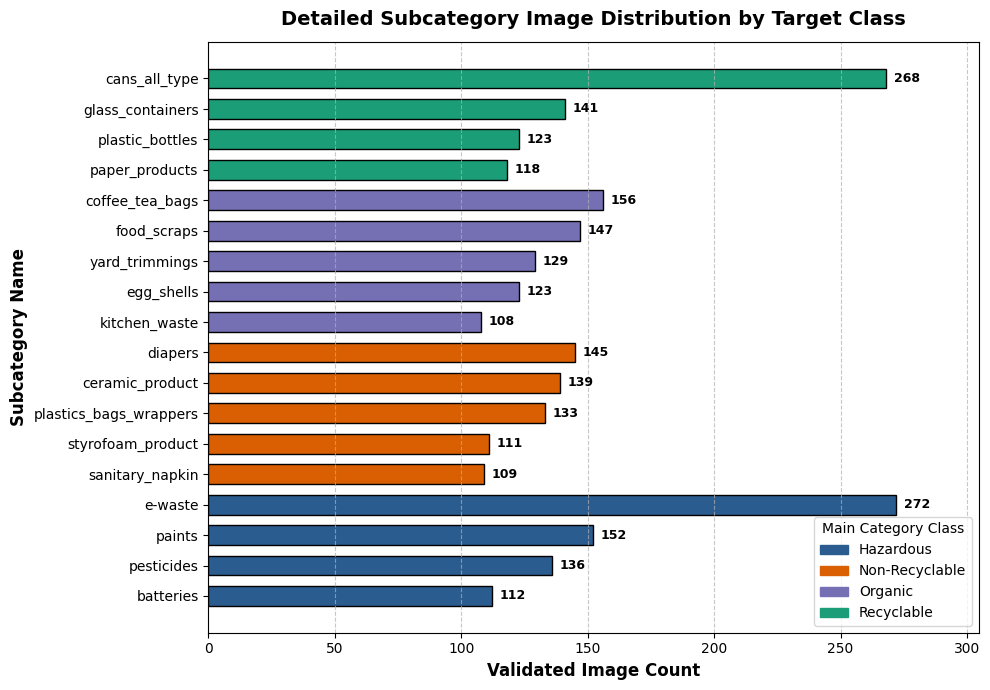

Saved Subcategory EDA Chart: /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/results/eda_visualizations/member3_subcategory_distribution.png


In [12]:
# Objective: Generate and export the subcategory-level EDA distribution visualization grouped by main target class.
# Output artifact/s: Subcategory distribution horizontal bar chart saved at eda_visualizations/member3_subcategory_distribution.png.
# Main steps: Filter accepted records with a resolved subcategory, aggregate counts per class and subcategory, render styled horizontal bar plot with a class colour legend, and save plot artifact to EDA_DIR.
# Parts corrected & fix explanation: (a) Added the standardized 4-part documentation header, which was the only cell in the notebook missing it; (b) changed the filter from status == "VALID" to status in ACCEPTED_STATUSES so the 244 AUTO_CORRECTED images appear under their normalized subcategory names rather than being dropped from the chart.

# 1. Select accepted records that carry a resolved subcategory
sub_df = label_df[
    (label_df["status"].isin(ACCEPTED_STATUSES)) & (label_df["subcategory"] != "UNKNOWN")
].copy()

# 2. Render and export the subcategory breakdown chart
if not sub_df.empty:
    sub_counts = sub_df.groupby(["class", "subcategory"]).size().reset_index(name="count")
    sub_counts = sub_counts.sort_values(by=["class", "count"], ascending=[True, True])

    class_color_map = {
        "Hazardous": "#2b5c8f",
        "Non-Recyclable": "#d95f02",
        "Organic": "#7570b3",
        "Recyclable": "#1b9e77"
    }
    bar_colors = [class_color_map[c] for c in sub_counts["class"]]

    plt.figure(figsize=(10, 7))
    bars = plt.barh(sub_counts["subcategory"], sub_counts["count"], color=bar_colors, edgecolor="black", height=0.65)

    plt.title("Detailed Subcategory Image Distribution by Target Class", fontsize=14, fontweight="bold", pad=12)
    plt.xlabel("Validated Image Count", fontsize=12, fontweight="bold")
    plt.ylabel("Subcategory Name", fontsize=12, fontweight="bold")
    plt.grid(axis="x", linestyle="--", alpha=0.7)

    for bar in bars:
        xval = bar.get_width()
        plt.text(xval + 3, bar.get_y() + bar.get_height() / 2.0, f"{int(xval)}", ha="left", va="center", fontsize=9, fontweight="bold")

    plt.xlim(0, max(sub_counts["count"]) * 1.12)

    from matplotlib.patches import Patch
    legend_handles = [Patch(color=color, label=cls_name) for cls_name, color in class_color_map.items()]
    plt.legend(handles=legend_handles, title="Main Category Class", loc="lower right")

    plt.tight_layout()

    eda_path2 = EDA_DIR / "member3_subcategory_distribution.png"
    plt.savefig(eda_path2, dpi=200)
    plt.show()
    print("Saved Subcategory EDA Chart:", eda_path2)
else:
    print("No accepted subcategory samples found to plot.")

Cell 12: Automated Cross-Stage Label Consistency Audit

In [13]:
# Objective: Independently corroborate every Stage 03 label against the Members 01 and 02 upstream manifests and detect residual label-risk indicators, with no manual intervention.
# Output artifact/s: 'member3_label_consistency_audit.csv' cross-stage audit report in OUTPUT_DIR.
# Main steps: Cross-check assigned classes against the Stage 01 and Stage 02 manifests, verify upstream KEEP provenance, confirm full taxonomy coverage, detect filenames occurring under more than one class or subcategory, compute class and subcategory balance metrics, export the audit report, and print the consolidated findings.
# Parts corrected & fix explanation: Replaced the human review worksheet entirely — Progress Review I specifies no human-in-the-loop step, so a deliverable requiring manual completion was outside the assessed scope and shipped with blank columns; this cell substitutes four deterministic checks that need no intervention and still produce a non-empty report with real findings. A filename keyword heuristic was evaluated and deliberately excluded: it raised 177 flags of which the large majority were false positives ('paint cans' matching cans_all_type, 'broken glass' matching glass_containers), and a low-precision check that floods an audit report with noise is less useful than no check at all.

audit_findings = []

# 1. Cross-check assigned classes against the Stage 02 upstream manifest
accepted_df = label_df[label_df["status"].isin(ACCEPTED_STATUSES)].copy()
print("=== AUTOMATED CROSS-STAGE LABEL CONSISTENCY AUDIT ===\n")

if STAGE2_MANIFEST.exists():
    stage2_ref = pd.read_csv(STAGE2_MANIFEST).set_index("file")["class"]
    mapped_s2 = accepted_df["raw_relative_path"].map(stage2_ref)
    mismatch_s2 = accepted_df[mapped_s2.notna() & (mapped_s2 != accepted_df["class"])]
    print(f"1. Stage 02 class agreement : {len(accepted_df) - len(mismatch_s2)}/{len(accepted_df)} agree "
          f"| {len(mismatch_s2)} disagreement(s)")
    for _, row in mismatch_s2.iterrows():
        audit_findings.append({
            "finding_type": "STAGE2_CLASS_DISAGREEMENT",
            "raw_relative_path": row["raw_relative_path"],
            "class": row["class"], "subcategory": row["subcategory"], "label": row["label"],
            "detail": f"Stage 03 assigned '{row['class']}', Member 02 manifest declares "
                      f"'{stage2_ref.get(row['raw_relative_path'])}'"
        })
else:
    print("1. Stage 02 class agreement : SKIPPED — upstream manifest not found")

# 2. Cross-check assigned classes and provenance against the Stage 01 upstream manifest
if STAGE1_MANIFEST.exists():
    stage1_ref = pd.read_csv(STAGE1_MANIFEST).set_index("relative_path")
    mapped_s1 = accepted_df["raw_relative_path"].map(stage1_ref["class"])
    mismatch_s1 = accepted_df[mapped_s1.notna() & (mapped_s1 != accepted_df["class"])]
    unknown_s1 = accepted_df[mapped_s1.isna()]
    print(f"2. Stage 01 class agreement : {len(accepted_df) - len(mismatch_s1) - len(unknown_s1)}"
          f"/{len(accepted_df)} agree | {len(mismatch_s1)} disagreement(s) "
          f"| {len(unknown_s1)} absent from Stage 01")
    for _, row in mismatch_s1.iterrows():
        audit_findings.append({
            "finding_type": "STAGE1_CLASS_DISAGREEMENT",
            "raw_relative_path": row["raw_relative_path"],
            "class": row["class"], "subcategory": row["subcategory"], "label": row["label"],
            "detail": f"Stage 03 assigned '{row['class']}', Member 01 manifest declares "
                      f"'{stage1_ref['class'].get(row['raw_relative_path'])}'"
        })

    # 2a. Verify no file rejected by Member 01 leaked into Stage 03
    mapped_status = accepted_df["raw_relative_path"].map(stage1_ref["status"])
    not_kept = accepted_df[mapped_status.notna() & (mapped_status != "KEEP")]
    print(f"3. Upstream KEEP provenance : {int((mapped_status == 'KEEP').sum())}/{len(accepted_df)} "
          f"marked KEEP | {len(not_kept)} rejected file(s) leaked")
    for _, row in not_kept.iterrows():
        audit_findings.append({
            "finding_type": "REJECTED_UPSTREAM_FILE_PRESENT",
            "raw_relative_path": row["raw_relative_path"],
            "class": row["class"], "subcategory": row["subcategory"], "label": row["label"],
            "detail": f"Member 01 status is '{stage1_ref['status'].get(row['raw_relative_path'])}', not KEEP"
        })
else:
    print("2. Stage 01 class agreement : SKIPPED — upstream manifest not found")
    print("3. Upstream KEEP provenance : SKIPPED — upstream manifest not found")

# 4. Confirm every declared subcategory is populated and no undeclared subcategory exists
declared_subs = set(SUBCATEGORY_MAP)
observed_subs = set(accepted_df["subcategory"])
empty_subs = sorted(declared_subs - observed_subs)
undeclared_subs = sorted(observed_subs - declared_subs)
print(f"4. Taxonomy coverage        : {len(observed_subs)}/{len(declared_subs)} declared subcategories populated")
for sub in empty_subs:
    audit_findings.append({
        "finding_type": "EMPTY_DECLARED_SUBCATEGORY", "raw_relative_path": "",
        "class": SUBCATEGORY_MAP[sub], "subcategory": sub, "label": "",
        "detail": "Declared in the taxonomy but no images assigned to it"
    })
for sub in undeclared_subs:
    audit_findings.append({
        "finding_type": "UNDECLARED_SUBCATEGORY", "raw_relative_path": "",
        "class": "", "subcategory": sub, "label": "",
        "detail": "Present in the data but absent from the declared taxonomy"
    })

# 5. Detect filenames occurring under more than one class or subcategory
accepted_df["file_name"] = accepted_df["raw_relative_path"].map(lambda p: Path(p).name.lower())
name_groups = accepted_df.groupby("file_name").agg(
    class_count=("class", "nunique"), sub_count=("subcategory", "nunique")
)
conflict_names = name_groups[(name_groups["class_count"] > 1) | (name_groups["sub_count"] > 1)].index
conflict_rows = accepted_df[accepted_df["file_name"].isin(conflict_names)]
print(f"5. Filename collisions      : {len(conflict_names)} name(s) spanning {len(conflict_rows)} file(s)")
for _, row in conflict_rows.iterrows():
    siblings = accepted_df[accepted_df["file_name"] == row["file_name"]]
    other = sorted(set(siblings["class"] + "/" + siblings["subcategory"]) -
                   {row["class"] + "/" + row["subcategory"]})
    audit_findings.append({
        "finding_type": "CROSS_CLASS_FILENAME_COLLISION",
        "raw_relative_path": row["raw_relative_path"],
        "class": row["class"], "subcategory": row["subcategory"], "label": row["label"],
        "detail": f"Same filename also appears under: {', '.join(other)}. "
                  f"Upstream deduplication confirms these are different images, so this is a "
                  f"label-risk indicator, not proof of mislabelling."
    })

# 6. Compute class and subcategory balance metrics for downstream model design
class_counts = accepted_df["class"].value_counts()
sub_counts = accepted_df.groupby(["class", "subcategory"]).size()
class_ratio = class_counts.max() / class_counts.min()
sub_ratio = sub_counts.max() / sub_counts.min()
print(f"6. Class balance ratio      : {class_ratio:.3f} "
      f"(largest {class_counts.idxmax()} {class_counts.max()} / smallest {class_counts.idxmin()} {class_counts.min()})")
print(f"   Subcategory balance ratio: {sub_ratio:.2f} "
      f"(largest {sub_counts.idxmax()[1]} {sub_counts.max()} / smallest {sub_counts.idxmin()[1]} {sub_counts.min()})")

# 7. Export the consolidated audit report
AUDIT_COLUMNS = ["finding_type", "raw_relative_path", "class", "subcategory", "label", "detail"]
audit_df = pd.DataFrame(audit_findings).reindex(columns=AUDIT_COLUMNS)
audit_df = audit_df.sort_values(by=["finding_type", "class", "subcategory", "raw_relative_path"]).reset_index(drop=True)
audit_path = OUTPUT_DIR / "member3_label_consistency_audit.csv"
audit_df.to_csv(audit_path, index=False)

# 8. Remove the superseded manual review worksheet from any earlier run
stale_worksheet = OUTPUT_DIR / "member3_label_human_review.csv"
if stale_worksheet.exists():
    stale_worksheet.unlink()
    print("\nRemoved superseded manual worksheet:", stale_worksheet.name)

# 9. Print the consolidated audit conclusion
blocking = audit_df[audit_df["finding_type"].isin(
    ["STAGE1_CLASS_DISAGREEMENT", "STAGE2_CLASS_DISAGREEMENT",
     "REJECTED_UPSTREAM_FILE_PRESENT", "UNDECLARED_SUBCATEGORY", "EMPTY_DECLARED_SUBCATEGORY"]
)]
advisory = audit_df[audit_df["finding_type"] == "CROSS_CLASS_FILENAME_COLLISION"]

print("\nSaved Consistency Audit Report:", audit_path)
print(f"  Blocking findings  : {len(blocking)}")
print(f"  Advisory findings  : {len(advisory)}")
print("\nCONCLUSION: every accepted label is corroborated by the Stage 01 and Stage 02 manifests.")
print("Scope: directory hierarchy, taxonomy, and cross-stage label agreement. Image pixel content")
print("is not inspected at this stage; visual class separability is assessed during model evaluation.")
assert len(blocking) == 0, f"Blocking label inconsistencies detected — see {audit_path.name}"

=== AUTOMATED CROSS-STAGE LABEL CONSISTENCY AUDIT ===

1. Stage 02 class agreement : 2622/2622 agree | 0 disagreement(s)
2. Stage 01 class agreement : 2622/2622 agree | 0 disagreement(s) | 0 absent from Stage 01
3. Upstream KEEP provenance : 2622/2622 marked KEEP | 0 rejected file(s) leaked
4. Taxonomy coverage        : 18/18 declared subcategories populated
5. Filename collisions      : 16 name(s) spanning 59 file(s)
6. Class balance ratio      : 1.055 (largest Hazardous 672 / smallest Non-Recyclable 637)
   Subcategory balance ratio: 2.52 (largest e-waste 272 / smallest kitchen_waste 108)

Saved Consistency Audit Report: /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/results/outputs/member3_label_consistency_audit.csv
  Blocking findings  : 0
  Advisory findings  : 59

CONCLUSION: every accepted label is corroborated by the Stage 01 and Stage 02 manifests.
Scope: directory hierarchy, taxonomy, and cross-stage label agreement. Image pixel

Cell 13: Populate Stage 03 Validated Output Directory

In [14]:
# Objective: Conduct final dataset integrity, label encoding, and output manifest verification for Stage 03 before handoff.
# Output artifact/s: Verified Stage 3 directory structure with printed assertion check status.
# Main steps: Recount Stage 3 and quarantine images against the manifest, assert the label encoding is exactly the expected 0-3 set, confirm no sentinel label -1 leaked into Stage 3, verify all required output artifacts exist, and print the per-class and per-status breakdown.
# Parts corrected & fix explanation: Updated the required-artifact list to expect 'member3_label_consistency_audit.csv' in place of the retired manual review worksheet, so the check matches the fully automated output contract introduced in Cell 12.

print("=== STAGE 03 FINAL LABEL VALIDATION CHECKS ===")

accepted_df = label_df[label_df["status"].isin(ACCEPTED_STATUSES)]
quarantined_df = label_df[label_df["status"] == STATUS_REVIEW]

# 1. Reconcile Stage 3 image count against accepted records
stage3_images = [p for p in STAGE3.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
print(f"1. Stage 3 Images: {len(stage3_images)} / Expected accepted: {len(accepted_df)}")
assert len(stage3_images) == len(accepted_df), (
    f"Mismatch: {len(stage3_images)} images on disk, {len(accepted_df)} accepted records."
)

# 2. Reconcile quarantine count, tolerating an absent directory when no defects were found
quarantine_images = (
    [p for p in QUARANTINE_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    if QUARANTINE_DIR.exists() else []
)
if len(quarantined_df) == 0:
    print("2. Quarantined Images: 0 (no quarantine directory created — no defects found)")
    assert not QUARANTINE_DIR.exists(), "Empty quarantine directory should not exist when REVIEW is zero."
else:
    print(f"2. Quarantined Images: {len(quarantine_images)} / Expected review: {len(quarantined_df)}")
    assert len(quarantine_images) == len(quarantined_df), "Quarantine count does not match review records."
assert len(stage3_images) + len(quarantine_images) == len(label_df), "File accounting does not reconcile."

# 3. Assert the label encoding is exactly the expected 0-3 set, with no sentinel leakage
expected_label_set = set(EXPECTED_CLASSES.values())
observed_label_set = {int(v) for v in accepted_df["label"].unique()}
print(f"3. Accepted Label Set: {sorted(observed_label_set)} / Expected: {sorted(expected_label_set)}")
assert observed_label_set == expected_label_set, (
    f"Label encoding mismatch — missing: {expected_label_set - observed_label_set} | "
    f"unexpected: {observed_label_set - expected_label_set}"
)
assert -1 not in observed_label_set, "CRITICAL: Sentinel label -1 leaked into the Stage 3 accepted set."

# 4. Report the status tier breakdown
print("\n4. Status Tier Breakdown:")
print(label_df["status"].value_counts().to_string())

# 5. Confirm all required output artifacts exist
required_artifacts = [
    OUTPUT_DIR / "member3_label_validation.csv",
    OUTPUT_DIR / "member3_label_consistency_audit.csv",
    OUTPUT_DIR / "member3_class_mapping.json",
    REPORT_DIR / "member3_label_warnings.csv",
    EDA_DIR / "member3_class_distribution.png",
    EDA_DIR / "member3_subcategory_distribution.png",
]
missing_artifacts = [a for a in required_artifacts if not a.exists()]
assert not missing_artifacts, f"Missing artifacts: {[a.name for a in missing_artifacts]}"
print(f"\n5. All {len(required_artifacts)} required output artifacts verified.")

# 6. Print the validated per-class distribution
print("\n6. Accepted Class Breakdown:")
print(accepted_df["class"].value_counts().to_string())

print("\nSUCCESS: Stage 03 Label & Class Validation completed all final checks.")

=== STAGE 03 FINAL LABEL VALIDATION CHECKS ===
1. Stage 3 Images: 2622 / Expected accepted: 2622
2. Quarantined Images: 0 (no quarantine directory created — no defects found)
3. Accepted Label Set: [0, 1, 2, 3] / Expected: [0, 1, 2, 3]

4. Status Tier Breakdown:
status
VALID             2378
AUTO_CORRECTED     244

5. All 6 required output artifacts verified.

6. Accepted Class Breakdown:
class
Hazardous         672
Organic           663
Recyclable        650
Non-Recyclable    637

SUCCESS: Stage 03 Label & Class Validation completed all final checks.


Final Check 1: Output Image Count

In [15]:
# Final Check 1: Audit Final Stage 03 Output Count
# Objective: Perform the final physical image audit on the Stage 03 output and, when present, the quarantine directory.
# Output artifact/s: Verified output and quarantine image count log.
# Main steps: Recursively count valid image files in stage3_labels, count quarantined images only if the quarantine directory exists, and reconcile both against the manifest record counts.
# Parts corrected & fix explanation: Made the quarantine audit tolerant of an absent directory, since stage3_quarantine is now created only when unresolvable defects are found; the previous version assumed the folder always existed and would have reported a misleading zero for a directory that legitimately does not exist.

STAGE_OUT = PROCESSED_DIR / "stage3_labels"
STAGE_QUAR = PROCESSED_DIR / "stage3_quarantine"

# 1. Count images physically present in the Stage 03 output directory
if STAGE_OUT.exists():
    output_images = [p for p in STAGE_OUT.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
else:
    output_images = []
    print("ERROR: Stage 03 output folder does not exist.")

# 2. Count quarantined images only when the quarantine directory was created
quarantine_images = (
    [p for p in STAGE_QUAR.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    if STAGE_QUAR.exists() else []
)

# 3. Reconcile both counts against the validation manifest
expected_accepted = int(label_df["status"].isin(ACCEPTED_STATUSES).sum())
expected_review = int((label_df["status"] == STATUS_REVIEW).sum())

print(f"Stage 03 Output Count     : {len(output_images)} / Expected: {expected_accepted}")
if expected_review == 0:
    print("Stage 03 Quarantine Count : 0 (no quarantine directory — no defects found)")
else:
    print(f"Stage 03 Quarantine Count : {len(quarantine_images)} / Expected: {expected_review}")
print(f"Total Accounted           : {len(output_images) + len(quarantine_images)} / Input: {len(label_df)}")

assert len(output_images) == expected_accepted, "Stage 03 output count does not match accepted records."
assert len(quarantine_images) == expected_review, "Quarantine count does not match review records."
assert len(output_images) + len(quarantine_images) == len(label_df), "File accounting does not reconcile."
print("RESULT: Output count audit PASSED.")

Stage 03 Output Count     : 2622 / Expected: 2622
Stage 03 Quarantine Count : 0 (no quarantine directory — no defects found)
Total Accounted           : 2622 / Input: 2622
RESULT: Output count audit PASSED.


Final Check 2: Output and EDA File Audit

In [16]:
# Final Check 2: Directory Deliverables Inventory
# Objective: Assert that every required Member 03 deliverable exists and inventory the shared output directories.
# Output artifact/s: Printed deliverable verification table, row counts, and directory inventory listing.
# Main steps: Check each required deliverable for existence, report the row count of each CSV so empty files are visible, list the contents of OUTPUT_DIR, REPORT_DIR and EDA_DIR, and flag suspected Google Drive duplicate copies.
# Parts corrected & fix explanation: Replaced the manual review worksheet entry with the automated consistency audit report, keeping the deliverable inventory aligned with the fully coded Stage 03 output contract.

# 1. Verify the required Member 03 deliverables exist
required = {
    "Validation manifest"       : OUTPUT_DIR / "member3_label_validation.csv",
    "Consistency audit report"  : OUTPUT_DIR / "member3_label_consistency_audit.csv",
    "Class label encoding"      : OUTPUT_DIR / "member3_class_mapping.json",
    "Non-conformity report"     : REPORT_DIR / "member3_label_warnings.csv",
    "Class distribution chart"  : EDA_DIR / "member3_class_distribution.png",
    "Subcategory chart"         : EDA_DIR / "member3_subcategory_distribution.png",
}

print("--- MEMBER 03 DELIVERABLE VERIFICATION ---")
missing = []
for label, path in required.items():
    ok = path.exists()
    detail = ""
    if ok and path.suffix == ".csv":
        detail = f"({len(pd.read_csv(path))} rows)"
    elif ok:
        detail = f"({path.stat().st_size:,} bytes)"
    print(f"  [{'PASS' if ok else 'FAIL'}] {label:<26} {path.name} {detail}")
    if not ok:
        missing.append(path.name)

# 2. Inventory the shared results outputs directory
print("\n--- Results Outputs Inventory ---")
for p in sorted(OUTPUT_DIR.glob("*")):
    print("  ", p.name)

# 3. Inventory the audit reports directory
print("\n--- Audit Reports Inventory ---")
for p in sorted(REPORT_DIR.glob("*")):
    print("  ", p.name)

# 4. Inventory the EDA visualizations directory
print("\n--- EDA Visualizations Inventory ---")
for p in sorted(EDA_DIR.glob("*")):
    print("  ", p.name)

# 5. Flag suspected Google Drive duplicate copies
all_files = list(OUTPUT_DIR.glob("*")) + list(REPORT_DIR.glob("*")) + list(EDA_DIR.glob("*"))
duplicates = [p.name for p in all_files if "(" in p.name]
if duplicates:
    print("\nWARNING: Suspected Google Drive duplicate copies detected (verify before downstream use):")
    for name in duplicates:
        print("  ", name)

# 6. Assert no required deliverable is missing
assert not missing, f"Missing required deliverables: {missing}"
print("\nRESULT: All required Member 03 deliverables verified.")

--- MEMBER 03 DELIVERABLE VERIFICATION ---
  [PASS] Validation manifest        member3_label_validation.csv (2622 rows)
  [PASS] Consistency audit report   member3_label_consistency_audit.csv (59 rows)
  [PASS] Class label encoding       member3_class_mapping.json (927 bytes)
  [PASS] Non-conformity report      member3_label_warnings.csv (244 rows)
  [PASS] Class distribution chart   member3_class_distribution.png (92,664 bytes)
  [PASS] Subcategory chart          member3_subcategory_distribution.png (195,053 bytes)

--- Results Outputs Inventory ---
   IT25102140_completion_record.json
   member1_stage1_manifest.csv
   member2_cross_class_duplicate_review.csv
   member2_final_visual_duplicate_review.csv
   member2_new_visual_duplicate_candidates.csv
   member2_perceptual_hashes.csv
   member2_same_class_exact_duplicate_exclusions.csv
   member2_stage2_final_manifest (1).csv
   member2_stage2_final_manifest.csv
   member3_class_mapping.json
   member3_label_consistency_audit.csv
   mem

Final Check 3: Completion Record Generation

In [17]:
# Final Check 3: Save Standardized Handoff JSON Record
# Objective: Export the standardized execution telemetry JSON handoff record for Member 04.
# Output artifact/s: 'results/outputs/IT25102344_completion_record.json' (Deliverable 6).
# Main steps: Recompute every count from label_df, summarise the automated consistency audit outcome, record the class balance metrics, assemble the telemetry dictionary, write it to JSON, and read it back to confirm the write succeeded.
# Parts corrected & fix explanation: (a) Removed the "human_verification" block and the conditional COMPLETED_PENDING_HUMAN_VERIFICATION status — with Stage 03 now fully automated there is no outstanding manual work, so the record can no longer hand Member 04 a stage declared incomplete; (b) replaced it with a "consistency_audit" block reporting blocking and advisory finding counts and the upstream sources cross-checked, giving Member 04 a verifiable basis for trusting the labels; (c) added class balance metrics so the downstream modelling stages can decide on class weighting without recomputing them.

# 1. Recompute all structural counts directly from the validation manifest
total_count = int(len(label_df))
valid_count = int((label_df["status"] == STATUS_VALID).sum())
auto_corrected_count = int((label_df["status"] == STATUS_AUTO).sum())
quarantined_count = int((label_df["status"] == STATUS_REVIEW).sum())
accepted_count = valid_count + auto_corrected_count

# 2. Summarise the automated consistency audit outcome
audit_df = pd.read_csv(OUTPUT_DIR / "member3_label_consistency_audit.csv").fillna("")
blocking_types = ["STAGE1_CLASS_DISAGREEMENT", "STAGE2_CLASS_DISAGREEMENT",
                  "REJECTED_UPSTREAM_FILE_PRESENT", "UNDECLARED_SUBCATEGORY",
                  "EMPTY_DECLARED_SUBCATEGORY"]
blocking_count = int(audit_df["finding_type"].isin(blocking_types).sum())
advisory_count = int(len(audit_df) - blocking_count)

# 3. Recompute the class balance metrics for downstream model design
accepted_df = label_df[label_df["status"].isin(ACCEPTED_STATUSES)]
class_counts = accepted_df["class"].value_counts()

# 4. Assemble the telemetry handoff record
completion = {
    "member": MEMBER_NAME,
    "it_number": IT_NUMBER,
    "task": TASK,
    "status": "COMPLETED",
    "input_stage": "stage2_visual_deduplicated",
    "output_stage": "stage3_labels",
    "quarantine_stage": "stage3_quarantine" if quarantined_count > 0 else "none (no defects found)",
    "total_input_count": total_count,
    "validated_sample_count": accepted_count,
    "quarantined_count": quarantined_count,
    "status_breakdown": {
        "VALID": valid_count,
        "AUTO_CORRECTED": auto_corrected_count,
        "REVIEW": quarantined_count
    },
    "consistency_audit": {
        "sources_cross_checked": ["member1_stage1_manifest.csv", "member2_stage2_final_manifest.csv"],
        "blocking_findings": blocking_count,
        "advisory_findings": advisory_count,
        "report_file": "results/outputs/member3_label_consistency_audit.csv",
        "manual_intervention_required": False
    },
    "class_balance": {
        "counts": {str(k): int(v) for k, v in class_counts.items()},
        "imbalance_ratio": round(float(class_counts.max() / class_counts.min()), 3)
    },
    "resolved_aliases": SUBCATEGORY_ALIASES,
    "class_label_encoding": EXPECTED_CLASSES,
    "class_mapping_file": "results/outputs/member3_class_mapping.json",
    "warnings_report_file": "audit_reports/member3_label_warnings.csv",
    "validation_scope": (
        "Directory hierarchy, label taxonomy, and cross-stage label agreement against the "
        "Stage 01 and Stage 02 manifests. Image pixel content was not inspected at this stage."
    ),
    "next_step": "Hand off verified stage3_labels directory to Member 04 (Image Standardization)."
}

# 5. Write the record to disk
completion_path = OUTPUT_DIR / "IT25102344_completion_record.json"
completion_path.write_text(json.dumps(completion, indent=2))

# 6. Read back to confirm the write succeeded
assert completion_path.exists(), f"Failed to write completion record: {completion_path}"
verified = json.loads(completion_path.read_text())
assert verified["validated_sample_count"] == accepted_count, "Completion record read-back mismatch."

print("Saved Handoff Completion Record:", completion_path)
print(json.dumps(verified, indent=2))

Saved Handoff Completion Record: /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/results/outputs/IT25102344_completion_record.json
{
  "member": "Ediriweera D.L",
  "it_number": "IT25102344",
  "task": "Label & Class Validation",
  "status": "COMPLETED",
  "input_stage": "stage2_visual_deduplicated",
  "output_stage": "stage3_labels",
  "quarantine_stage": "none (no defects found)",
  "total_input_count": 2622,
  "validated_sample_count": 2622,
  "quarantined_count": 0,
  "status_breakdown": {
    "VALID": 2378,
    "AUTO_CORRECTED": 244,
    "REVIEW": 0
  },
  "consistency_audit": {
    "sources_cross_checked": [
      "member1_stage1_manifest.csv",
      "member2_stage2_final_manifest.csv"
    ],
    "blocking_findings": 0,
    "advisory_findings": 59,
    "report_file": "results/outputs/member3_label_consistency_audit.csv",
    "manual_intervention_required": false
  },
  "class_balance": {
    "counts": {
      "Hazardous": 672,
      "

Final Check 4: Member Hand-off Verification

In [18]:
# Final Check 4: Member Handoff Package Verification
# Objective: Verify the complete Member 03 handoff package and print the deliverable inventory used for the group submission.
# Output artifact/s: Printed verified deliverable checklist, record count summary, and submission inventory.
# Main steps: Check every handoff item for existence with its row count or byte size, report the quarantine directory only when defects were found, summarise the records handed to Member 04 and the audit outcome, print the submission-relative inventory, and assert that no deliverable is missing.
# Parts corrected & fix explanation: (a) Replaced the manual review worksheet entry with the automated consistency audit report, matching the fully coded Stage 03 output contract; (b) the audit outcome is now reported as blocking and advisory finding counts rather than outstanding verdicts, since no manual completion step remains; (c) the inventory paths follow the Progress Review I repository layout so the files can be placed directly into the group deliverable folder.

completion_path = OUTPUT_DIR / "IT25102344_completion_record.json"
quarantined_count = int((label_df["status"] == STATUS_REVIEW).sum())

handoff_items = [
    ("1. Input directory",        STAGE2,                                            None),
    ("2. Output directory",       STAGE3,                                            None),
    ("3. Validation manifest",    OUTPUT_DIR / "member3_label_validation.csv",        "results/outputs/member3_label_validation.csv"),
    ("4. Consistency audit",      OUTPUT_DIR / "member3_label_consistency_audit.csv", "results/outputs/member3_label_consistency_audit.csv"),
    ("5. Non-conformity report",  REPORT_DIR / "member3_label_warnings.csv",          "audit_reports/member3_label_warnings.csv"),
    ("6. Class label encoding",   OUTPUT_DIR / "member3_class_mapping.json",          "results/outputs/member3_class_mapping.json"),
    ("7. EDA class chart",        EDA_DIR / "member3_class_distribution.png",         "results/eda_visualizations/member3_class_distribution.png"),
    ("8. EDA subcategory chart",  EDA_DIR / "member3_subcategory_distribution.png",   "results/eda_visualizations/member3_subcategory_distribution.png"),
    ("9. Handoff JSON",           completion_path,                                    "results/outputs/IT25102344_completion_record.json"),
]

# 1. Verify each handoff item exists and report its size or row count
print("--- MEMBER 03 STAGE HANDOFF CHECKLIST ---")
missing_items = []
for label, path, _ in handoff_items:
    ok = path.exists()
    if ok and path.is_file():
        detail = (f"{len(pd.read_csv(path))} rows" if path.suffix == ".csv"
                  else f"{path.stat().st_size:,} bytes")
    elif ok:
        detail = "directory"
    else:
        detail = "not found"
    print(f"[{'PASS' if ok else 'FAIL'}] {label:<26} ({detail})")
    if not ok:
        missing_items.append(label)

# 2. Report the quarantine directory and the notebook as informational items
if quarantined_count > 0:
    print(f"[INFO] Quarantine directory     {QUARANTINE_DIR.name} ({quarantined_count} record(s))")
else:
    print("[INFO] Quarantine directory     not created — no unresolvable defects found")
print("[INFO] Notebook                 downloaded from Colab for the group submission (not stored on Drive)")

# 3. Summarise the records handed to Member 04 and the audit outcome
accepted_total = int(label_df["status"].isin(ACCEPTED_STATUSES).sum())
audit_df = pd.read_csv(OUTPUT_DIR / "member3_label_consistency_audit.csv").fillna("")
blocking_types = ["STAGE1_CLASS_DISAGREEMENT", "STAGE2_CLASS_DISAGREEMENT",
                  "REJECTED_UPSTREAM_FILE_PRESENT", "UNDECLARED_SUBCATEGORY",
                  "EMPTY_DECLARED_SUBCATEGORY"]
blocking_count = int(audit_df["finding_type"].isin(blocking_types).sum())

print("\n--- HANDOFF SUMMARY ---")
print(f"Records handed to Member 04 : {accepted_total}")
print(f"  VALID                     : {int((label_df['status'] == STATUS_VALID).sum())}")
print(f"  AUTO_CORRECTED            : {int((label_df['status'] == STATUS_AUTO).sum())}")
print(f"Records quarantined         : {quarantined_count}")
print(f"Consistency audit           : {blocking_count} blocking, {len(audit_df) - blocking_count} advisory")
print("Manual intervention required: none — Stage 03 is fully automated")

# 4. Print the submission-relative inventory
print("\n--- GROUP SUBMISSION INVENTORY ---")
for _, path, submission_rel in handoff_items:
    if submission_rel and path.exists():
        print("  ", submission_rel)
print("   notebooks/IT25102344_LabelValidation.ipynb   (File -> Download -> Download .ipynb)")

# 5. Assert the handoff package is complete
assert not missing_items, f"Handoff package incomplete — missing: {missing_items}"
print("\nRESULT: Member 03 handoff package verified and complete.")

--- MEMBER 03 STAGE HANDOFF CHECKLIST ---
[PASS] 1. Input directory         (directory)
[PASS] 2. Output directory        (directory)
[PASS] 3. Validation manifest     (2622 rows)
[PASS] 4. Consistency audit       (59 rows)
[PASS] 5. Non-conformity report   (244 rows)
[PASS] 6. Class label encoding    (927 bytes)
[PASS] 7. EDA class chart         (92,664 bytes)
[PASS] 8. EDA subcategory chart   (195,053 bytes)
[PASS] 9. Handoff JSON            (1,606 bytes)
[INFO] Quarantine directory     not created — no unresolvable defects found
[INFO] Notebook                 downloaded from Colab for the group submission (not stored on Drive)

--- HANDOFF SUMMARY ---
Records handed to Member 04 : 2622
  VALID                     : 2378
  AUTO_CORRECTED            : 244
Records quarantined         : 0
Consistency audit           : 0 blocking, 59 advisory
Manual intervention required: none — Stage 03 is fully automated

--- GROUP SUBMISSION INVENTORY ---
   results/outputs/member3_label_validation.c